# Testing classifiers and models

In [6]:
import os

# path to Google drive
GDRIVE_PATH = os.path.expanduser('~/RealEyes/gdrive')

# check
if os.path.exists(GDRIVE_PATH):
    print(f"✅ Google Drive connected at: {GDRIVE_PATH}")
    folders = os.listdir(GDRIVE_PATH)
    print(f"📁 Available folders: {folders}")
else:
    print("❌ Error: Google Drive not mounted!")

# path to the folders
CODE_PATH = os.path.join(GDRIVE_PATH, 'code')
DATA_PATH = os.path.join(GDRIVE_PATH, 'data_set')
DATA_SPLIT_PATH = os.path.join(GDRIVE_PATH, 'data_set_split')

print(f"\n📂 Paths:")
print(f"   Code: {CODE_PATH}")
print(f"   Data: {DATA_PATH}")
print(f"   Data Split: {DATA_SPLIT_PATH}")

✅ Google Drive connected at: /home/sceuser/RealEyes/gdrive
📁 Available folders: ['code', 'data_set', 'data_set_split', 'kaggle.json', 'חידודים פרויקט גמר', 'מאמרים', 'מסמכים בעבודה', 'מסמכים שהוגשו', 'מצגת הצגה לפרויקט גמר חברתי.pptx']

📂 Paths:
   Code: /home/sceuser/RealEyes/gdrive/code
   Data: /home/sceuser/RealEyes/gdrive/data_set
   Data Split: /home/sceuser/RealEyes/gdrive/data_set_split


In [9]:
import os
import subprocess

# צור תיקייה ל-kaggle config
kaggle_dir = os.path.expanduser('~/.config/kaggle')
os.makedirs(kaggle_dir, exist_ok=True)
print(f"✅ Created directory: {kaggle_dir}")

# העתק את kaggle.json
source = os.path.join(GDRIVE_PATH, 'kaggle.json')
dest = os.path.join(kaggle_dir, 'kaggle.json')

if os.path.exists(source):
    import shutil
    shutil.copy(source, dest)
    print(f"✅ Copied kaggle.json from: {source}")
    print(f"   to: {dest}")

    # קבע הרשאות
    os.chmod(dest, 0o600)
    print(f"✅ Set permissions: 600")
else:
    print(f"❌ kaggle.json not found at: {source}")
    print(f"   Check GDRIVE_PATH: {GDRIVE_PATH}")

# בדיקה שזה עובד
kaggle_path = os.path.expanduser('~/.virtualenvs/deepfake_final_project/bin/kaggle')
if os.path.exists(kaggle_path):
    result = subprocess.run([kaggle_path, 'datasets', 'list', '--max-size', '1000'],
                           capture_output=True, text=True)
    print("\n📊 Kaggle datasets (first 10):")
    print('\n'.join(result.stdout.split('\n')[:10]))
else:
    print(f"❌ Kaggle not found at: {kaggle_path}")

✅ Created directory: /home/sceuser/.config/kaggle
✅ Copied kaggle.json from: /home/sceuser/RealEyes/gdrive/kaggle.json
   to: /home/sceuser/.config/kaggle/kaggle.json
✅ Set permissions: 600

📊 Kaggle datasets (first 10):
ref                                                             title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  -------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
liamarden/bloxd-io-games                                        bloxd.io games                                             587  2025-11-30 00:27:46.150000            160         21  0.9411765        
chrissyserb/meta-ai-timestamp-recognition-christine-classy      Meta AI Timestamp Recognition — Christine Classy™          416  2025-12-23 00:34:44.147000              0          

In [10]:
import os
import subprocess
from pathlib import Path
import zipfile
import glob

# full path to kaggle
KAGGLE_PATH = os.path.expanduser('~/.virtualenvs/deepfake_final_project/bin/kaggle')

# make folders
Path('./datasets/OpenForensicsV1').mkdir(parents=True, exist_ok=True)
Path('./datasets/cifake').mkdir(parents=True, exist_ok=True)

# download from kaggle
print("📥 Downloading OpenForensics dataset...")
subprocess.run([KAGGLE_PATH, 'datasets', 'download', 'manjilkarki/deepfake-and-real-images',
                '-p', './datasets/OpenForensicsV1'], check=True)

print("📥 Downloading CiFake dataset...")
subprocess.run([KAGGLE_PATH, 'datasets', 'download', 'birdy654/cifake-real-and-ai-generated-synthetic-images',
                '-p', './datasets/cifake'], check=True)

# extract from zip
print("📦 Extracting datasets...")

for zip_file in glob.glob('./datasets/OpenForensicsV1/*.zip'):
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall('./datasets/OpenForensicsV1/')
    print(f"✅ Extracted: {zip_file}")

for zip_file in glob.glob('./datasets/cifake/*.zip'):
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall('./datasets/cifake/')
    print(f"✅ Extracted: {zip_file}")

print("✅ All datasets downloaded and extracted!")

📥 Downloading OpenForensics dataset...
Dataset URL: https://www.kaggle.com/datasets/manjilkarki/deepfake-and-real-images
License(s): unknown
deepfake-and-real-images.zip: Skipping, found more recently modified local copy (use --force to force download)
📥 Downloading CiFake dataset...
Dataset URL: https://www.kaggle.com/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images
License(s): other
cifake-real-and-ai-generated-synthetic-images.zip: Skipping, found more recently modified local copy (use --force to force download)
📦 Extracting datasets...
✅ Extracted: ./datasets/OpenForensicsV1/deepfake-and-real-images.zip
✅ Extracted: ./datasets/cifake/cifake-real-and-ai-generated-synthetic-images.zip
✅ All datasets downloaded and extracted!


# Deep Learning Models

#do not run again this cell

In [7]:
#do not run again this cell- only for instal packages
import subprocess
import sys

print("Installing TensorFlow...")
result = subprocess.run([sys.executable, '-m', 'pip', 'install', 'tensorflow'],
                       capture_output=True, text=True)
print(result.stdout)
print(result.stderr)
print("\nDone!")

Installing TensorFlow...
  Obtaining dependency information for tensorflow from https://files.pythonhosted.org/packages/9c/d1/6aa15085d672056d5f08b5f28b1c7ce01c4e12149a23b0c98e3c79d04441/tensorflow-2.20.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata
  Using cached tensorflow-2.20.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.5 kB)
  Obtaining dependency information for absl-py>=1.0.0 from https://files.pythonhosted.org/packages/8f/aa/ba0014cc4659328dc818a28827be78e6d97312ab0cb98105a770924dc11e/absl_py-2.3.1-py3-none-any.whl.metadata
  Using cached absl_py-2.3.1-py3-none-any.whl.metadata (3.3 kB)
  Obtaining dependency information for astunparse>=1.6.0 from https://files.pythonhosted.org/packages/2b/03/13dde6512ad7b4557eb792fbcf0c653af6076b81e5941d36ec61f7ce6028/astunparse-1.6.3-py2.py3-none-any.whl.metadata
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Obtaining dependency information for flatbuffers>=24.3.25 

##SRM + CONV-AE + NA-VGG

In [11]:
import tensorflow as tf
import numpy as np

class SRMLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(SRMLayer, self).__init__(**kwargs)

        # Define the filters
        srm_filters = np.array([
            # Filter 1: Laplacian-High Boost
            [[[0, 0, -1, 0, 0],
              [0, -1, 2, -1, 0],
              [-1, 2, 4, 2, -1],
              [0, -1, 2, -1, 0],
              [0, 0, -1, 0, 0]]],

            # Filter 2: Edge & Noise Enhancer
            [[[-1, 2, -2, 2, -1],
              [2, -6, 8, -6, 2],
              [-2, 8, -12, 8, -2],
              [2, -6, 8, -6, 2],
              [-1, 2, -2, 2, -1]]],

            # Filter 3: Diagonal Residual Capture
            [[[2, -1, 0, -1, 2],
              [-1, -2, 3, -2, -1],
              [0, 3, 0, 3, 0],
              [-1, -2, 3, -2, -1],
              [2, -1, 0, -1, 2]]],

            # Filter 4: Vertical Edge Residuals
            [[[0, 0, 0, 0, 0],
              [1, -2, 1, -2, 1],
              [0, 0, 0, 0, 0],
              [-1, 2, -1, 2, -1],
              [0, 0, 0, 0, 0]]],

            # Filter 5: High Frequency Noise Extractor
            [[[1, -4, 6, -4, 1],
              [-4, 16, -24, 16, -4],
              [6, -24, 36, -24, 6],
              [-4, 16, -24, 16, -4],
              [1, -4, 6, -4, 1]]],
        ], dtype=np.float32)

        # (filter_height, filter_width, in_channels, out_channels)
        self.srm_filters_tf = tf.constant(np.transpose(srm_filters, (2, 3, 1, 0)), dtype=tf.float32)

    def call(self, inputs):
        # inputs shape: (batch, height, width, 3)
        channels = tf.split(inputs, num_or_size_splits=3, axis=-1)  # List of (batch, h, w, 1)
        feature_maps = []
        for channel in channels:
            # Apply SRM filters
            fm = tf.nn.conv2d(channel, self.srm_filters_tf, strides=1, padding='SAME')
            feature_maps.append(fm)

        # Concatenate across channels: (batch, h, w, 15)
        return tf.concat(feature_maps, axis=-1)

2025-12-27 22:02:41.303059: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-27 22:02:41.373918: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-27 22:02:45.103990: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/home/sceuser/.virtualenvs/deepfake_final_project/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


#RUN - HERE

In [12]:
import numpy as np
import tensorflow as tf
#import cv2
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model
import os
import h5py
import mimetypes
from tqdm import tqdm

# Auto-detect GPU or CPU
print("🔍 Checking for available hardware...")

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    try:
        # GPU found - configure it
        tf.config.set_visible_devices(gpus[0], 'GPU')
        # Set memory growth to avoid taking all GPU memory at once
        tf.config.experimental.set_memory_growth(gpus[0], True)
        logical_gpus = tf.config.list_logical_devices('GPU')
        print(f"✅ GPU DETECTED: Running on {gpus[0].name}")
        print(f"   Physical GPUs: {len(gpus)}, Logical GPUs: {len(logical_gpus)}")
    except RuntimeError as e:
        print(f"⚠️ GPU configuration error: {e}")
        print("🖥️ Falling back to CPU")
else:
    # No GPU - use CPU
    os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
    print("🖥️ NO GPU DETECTED: Running on CPU")
    print("⏰ Note: Training will be slower on CPU but will work correctly")

print("=" * 60)

# Define SRM filters (simplified example with 5 filters)
srm_filters = np.array([
    # Filter 1: Laplacian-High Boost
    [[[0, 0, -1, 0, 0],
      [0, -1, 2, -1, 0],
      [-1, 2, 4, 2, -1],
      [0, -1, 2, -1, 0],
      [0, 0, -1, 0, 0]]],

    # Filter 2: Edge & Noise Enhancer
    [[[-1, 2, -2, 2, -1],
      [2, -6, 8, -6, 2],
      [-2, 8, -12, 8, -2],
      [2, -6, 8, -6, 2],
      [-1, 2, -2, 2, -1]]],

    # Filter 3: Diagonal Residual Capture
    [[[2, -1, 0, -1, 2],
      [-1, -2, 3, -2, -1],
      [0, 3, 0, 3, 0],
      [-1, -2, 3, -2, -1],
      [2, -1, 0, -1, 2]]],

    # Filter 4: Vertical Edge Residuals
    [[[0, 0, 0, 0, 0],
      [1, -2, 1, -2, 1],
      [0, 0, 0, 0, 0],
      [-1, 2, -1, 2, -1],
      [0, 0, 0, 0, 0]]],

    # Filter 5: High Frequency Noise Extractor
    [[[1, -4, 6, -4, 1],
      [-4, 16, -24, 16, -4],
      [6, -24, 36, -24, 6],
      [-4, 16, -24, 16, -4],
      [1, -4, 6, -4, 1]]],
], dtype=np.float32)

srm_filters_tf = tf.constant(np.transpose(srm_filters, (2, 3, 1, 0)), dtype=tf.float32)  # (5, 5, 1, 5)

def apply_srm_filters_tf(image):
    """Apply SRM filters using TensorFlow for GPU acceleration."""
    image = tf.image.resize(image, [256, 256])  # Resize to 256x256
    # Split into R, G, B channels
    channels = tf.split(image, num_or_size_splits=3, axis=-1)  # List of (batch, 256, 256, 1)
    feature_maps = []
    for channel in channels:
        # Apply all 5 filters to this channel
        fm = tf.nn.conv2d(channel, srm_filters_tf, strides=1, padding='SAME')  # (batch, 256, 256, 5)
        feature_maps.append(fm)
    # Concatenate feature maps: (batch, 256, 256, 15)
    return tf.concat(feature_maps, axis=-1)

def load_dataset_images(dataset_path, max_images=None):
    """Load image paths and labels from a dataset directory, filtering valid image formats."""
    image_paths = []
    labels = []
    valid_extensions = {'.jpg', '.jpeg', '.png', '.gif', '.bmp'}

    folders = os.listdir(dataset_path)
    for label, folder in enumerate(folders):
        path = os.path.join(dataset_path, folder)
        if not os.path.isdir(path):
            continue
        for i, filename in enumerate(os.listdir(path)):
            if max_images and i >= max_images:
                break
            file_path = os.path.join(path, filename)
            # Check file extension
            ext = os.path.splitext(filename)[1].lower()
            if ext not in valid_extensions:
                print(f"Skipping non-image file: {file_path}")
                continue
            # Check MIME type for additional validation
            mime_type, _ = mimetypes.guess_type(file_path)
            if mime_type not in {'image/jpeg', 'image/png', 'image/gif', 'image/bmp'}:
                print(f"Skipping invalid format: {file_path} (MIME: {mime_type})")
                continue
            image_paths.append(file_path)
            labels.append(label)

    print(f"Loaded {len(image_paths)} valid images from {dataset_path}")
    return image_paths, np.array(labels)

def build_autoencoder(input_shape=(256, 256, 15), latent_dim=256):
    """Build a convolutional autoencoder with smaller latent size."""
    input_img = Input(shape=input_shape)
    # Encoder
    x = Conv2D(15, (3, 3), activation='elu', padding='same')(input_img)
    x = MaxPooling2D((2, 2), padding='same')(x)  # 128x128x15
    x = Conv2D(32, (3, 3), activation='elu', padding='same')(x)
    x = MaxPooling2D((2, 2), padding='same')(x)  # 64x64x32
    x = Conv2D(64, (3, 3), activation='elu', padding='same')(x)
    x = MaxPooling2D((2, 2), padding='same')(x)  # 32x32x64
    x = Conv2D(128, (3, 3), activation='elu', padding='same')(x)
    x = MaxPooling2D((2, 2), padding='same')(x)  # 16x16x128
    x = Conv2D(latent_dim, (3, 3), activation='elu', padding='same')(x)
    encoded = MaxPooling2D((2, 2), padding='same', name='encoder_output')(x)  # 8x8x256

    # Decoder
    x = Conv2D(latent_dim, (3, 3), activation='elu', padding='same')(encoded)
    x = UpSampling2D((2, 2))(x)  # 16x16x256
    x = Conv2D(128, (3, 3), activation='elu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)  # 32x32x128
    x = Conv2D(64, (3, 3), activation='elu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)  # 64x64x64
    x = Conv2D(32, (3, 3), activation='elu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)  # 128x128x32
    x = Conv2D(15, (3, 3), activation='elu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)  # 256x256x15
    decoded = Conv2D(15, (3, 3), activation='linear', padding='same')(x)

    autoencoder = Model(input_img, decoded)
    encoder = Model(input_img, encoded)
    autoencoder.compile(optimizer=Adam(learning_rate=0.00005), loss='mse')
    return autoencoder, encoder

def train_autoencoder(autoencoder, train_image_paths, val_image_paths, batch_size=64):
    """Train the autoencoder using a tf.data pipeline."""
    def process_image(path):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.cast(img, tf.float32) / 255.0
        fm = apply_srm_filters_tf(img[tf.newaxis, ...])[0]  # Remove batch dim
        return fm, fm

    train_dataset = tf.data.Dataset.from_tensor_slices(train_image_paths)
    train_dataset = train_dataset.map(process_image, num_parallel_calls=tf.data.AUTOTUNE)
    train_dataset = train_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    val_dataset = tf.data.Dataset.from_tensor_slices(val_image_paths)
    val_dataset = val_dataset.map(process_image, num_parallel_calls=tf.data.AUTOTUNE)
    val_dataset = val_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return autoencoder.fit(train_dataset, epochs=40, verbose=1, shuffle=True, validation_data=val_dataset)

def extract_latent_representations(encoder, image_paths, labels, output_h5, latent_size, batch_size=32):
    """Extract and save latent representations in batches to an HDF5 file."""
    def process_image(path):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.cast(img, tf.float32) / 255.0
        return apply_srm_filters_tf(img[tf.newaxis, ...])[0]

    dataset = tf.data.Dataset.from_tensor_slices(image_paths)
    dataset = dataset.map(process_image, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    with h5py.File(output_h5, 'a') as f:
        latent_shape = (len(image_paths), latent_size)  # Flattened latent size
        latent_dset = f.create_dataset('latent', shape=latent_shape, dtype=np.float32)
        labels_dset = f.create_dataset('labels', data=labels)

        start_idx = 0
        for batch in tqdm(dataset):
            latent = encoder.predict(batch, verbose=0)
            latent = latent.reshape(len(batch), -1)  # Flatten (batch_size, latent_size) to (batch_size, n*m*l)
            end_idx = start_idx + len(batch)
            latent_dset[start_idx:end_idx] = latent
            start_idx = end_idx

🔍 Checking for available hardware...
🖥️ NO GPU DETECTED: Running on CPU
⏰ Note: Training will be slower on CPU but will work correctly


2025-12-27 22:02:50.368507: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [14]:
#do not run again- this is is for install package
import subprocess
import sys

result = subprocess.run([sys.executable, '-m', 'pip', 'show', 'tf_keras'],
                       capture_output=True, text=True)
print(result.stdout)

## code for split data set- **do not run again**

In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split
from pathlib import Path

# ======================= define paths =======================

DRIVE_ROOT = Path(GDRIVE_PATH)

SOURCE_DIR = DRIVE_ROOT / 'data_set'

# 3. The new path where the train/val/test folders will be created
OUTPUT_DIR = DRIVE_ROOT / 'data_set_split'

# Split ratio: 80% training, 10% validation, 10% testing
TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1

# ======================= split function and copy =======================

def split_data(source_dir: Path, output_dir: Path, train_ratio, val_ratio, test_ratio):
    print(f"Starting split from {source_dir} to {output_dir}")

    # Critical check: Make sure the source folder exists
    if not source_dir.exists():
        print(f" FATAL ERROR: Source Directory not found: {source_dir}")
        print("    Please check that 'data_set' exists inside 'deepfake_image_project' in your Google Drive.")
        return

    # division to real and fake
    for label in ['REAL', 'FAKE']:
        label_dir = source_dir / label
        if not label_dir.exists():
            print(f"Directory not found: {label_dir}. Skipping {label}.")
            continue

        all_files = [f for f in os.listdir(label_dir) if (label_dir / f).is_file()]

        # 1. Train/Temp split (80% / 20%)
        train_files, temp_files = train_test_split(all_files, test_size=(val_ratio + test_ratio), random_state=42)

        # 2. Val/Test split from Temp
        val_files, test_files = train_test_split(temp_files, test_size=(test_ratio / (val_ratio + test_ratio)), random_state=42)

        # 3. create and copy
        splits = {'train': train_files, 'val': val_files, 'test': test_files}

        for split_name, file_list in splits.items():
            target_dir = output_dir / split_name / label
            os.makedirs(target_dir, exist_ok=True) # ודא שהתיקיות נוצרות

            print(f"Copying {len(file_list)} files for {label}/{split_name}...")
            for f in file_list:
                shutil.copy(label_dir / f, target_dir / f)

    print(f"✅ Split complete! New dataset created at {OUTPUT_DIR}")

# operation function
split_data(SOURCE_DIR, OUTPUT_DIR, TRAIN_RATIO, VAL_RATIO, TEST_RATIO)

Starting split from /content/drive/MyDrive/deepfake_image_project/data_set to /content/drive/MyDrive/deepfake_image_project/data_set_split
Copying 322 files for REAL/train...


KeyboardInterrupt: 

In [13]:
#=================== Main pipeline ===================#

#Drive Path
drive_path = GDRIVE_PATH + '/'

DATASET_ROOT = f'{drive_path}data_set_split/'

#Train set
train_datasets = {
    'CiFake': './datasets/cifake/train',
    'OpenForensics': './datasets/OpenForensicsV1/Dataset/Train',
    'CustomWar': f'{DATASET_ROOT}train'
}

# Validation set
validation_datasets = {
    'CiFake': './datasets/cifake/test',
    'OpenForensics': './datasets/OpenForensicsV1/Dataset/Validation',
    'CustomWar': f'{DATASET_ROOT}val'
}

# Test set
test_datasets = {
    'CiFake': './datasets/cifake/test',
    'OpenForensics': './datasets/OpenForensicsV1/Dataset/Test',
    'CustomWar': f'{DATASET_ROOT}test'
}

In [14]:
# Step 1: Prepare training and validation data for autoencoder
train_image_paths = []
train_labels = []
for name, path in train_datasets.items():
    img_paths, labels = load_dataset_images(path, max_images=5000 if name != 'CustomWar' else None)
    train_image_paths.extend(img_paths)
    train_labels.extend(labels)

validation_image_paths = []
val_labels = []
for name, path in validation_datasets.items():
    img_paths, labels = load_dataset_images(path, max_images=2000 if name != 'CustomWar' else None)
    validation_image_paths.extend(img_paths)
    val_labels.extend(labels)

test_image_paths = []
test_labels = []
for name, path in test_datasets.items():
    img_paths, labels = load_dataset_images(path)
    test_image_paths.extend(img_paths)
    test_labels.extend(labels)

Loaded 10000 valid images from ./datasets/cifake/train
Loaded 10000 valid images from ./datasets/OpenForensicsV1/Dataset/Train
Skipping non-image file: /home/sceuser/RealEyes/gdrive/data_set_split/train/REAL/image_0273.webp
Skipping non-image file: /home/sceuser/RealEyes/gdrive/data_set_split/train/REAL/image_0274.webp
Skipping non-image file: /home/sceuser/RealEyes/gdrive/data_set_split/train/REAL/image_0275.webp
Skipping non-image file: /home/sceuser/RealEyes/gdrive/data_set_split/train/REAL/image_0276.webp
Skipping non-image file: /home/sceuser/RealEyes/gdrive/data_set_split/train/REAL/image_0277.webp
Skipping non-image file: /home/sceuser/RealEyes/gdrive/data_set_split/train/REAL/image_0278.webp
Skipping non-image file: /home/sceuser/RealEyes/gdrive/data_set_split/train/REAL/image_0388.avif
Loaded 1637 valid images from /home/sceuser/RealEyes/gdrive/data_set_split/train
Loaded 4000 valid images from ./datasets/cifake/test
Loaded 4000 valid images from ./datasets/OpenForensicsV1/Dat

#NOT RUN - Already Completed

DO NOT RUN THIS SECTION

* This code was already executed by the previous team:

    1.   Autoencoder trained: code/models/ae/openforensics/autoencoder_L256.keras
    2.    Model ready for use

* The H5 latent files approach is NOT used in the current pipeline.
The GARBAGE COLLECTOR section below loads the autoencoder directly
and processes images on-the-fly using create_srm_dataset().

* Keeping this code for documentation purposes only.

In [ ]:
# Step 2.1: Build and train autoencoder
autoencoder, encoder = build_autoencoder(latent_dim=256)
#history = train_autoencoder(autoencoder, train_image_paths, validation_image_paths, 256)

In [ ]:
from matplotlib import pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
# Save autoencoder
from datetime import datetime
latent_size = encoder.output_shape[1] * encoder.output_shape[2] * encoder.output_shape[3]

autoencoder.save(f'{drive_path}models/AutoEncoder/autoencoder_256_openforensics_{datetime.now().strftime("%d-%m-%Y_%H-%M-%S")}.keras')

In [ ]:
from datetime import datetime
import os
import h5py

print("Step 3: Creating unified latent space files for each dataset...")

# Process all splits and append to H5 files per dataset split
for split_name, dataset_dict in [('train', train_datasets), ('val', validation_datasets), ('test', test_datasets)]:
    print(f"Extracting {split_name} latent representations...")

    for dataset_name, path in dataset_dict.items():
        print(f"Processing {dataset_name} ({split_name})...")

        image_paths, labels = load_dataset_images(path)
        latent_size = encoder.output_shape[1] * encoder.output_shape[2] * encoder.output_shape[3]

        # Build the full folder path based on split
        folder_path = os.path.join(drive_path, "latent", dataset_name, split_name)
        os.makedirs(folder_path, exist_ok=True)

        output_h5 = os.path.join(folder_path, f"{dataset_name}_{split_name}_latent_size_{latent_size}_v1.h5")

        # If file exists, delete to avoid HDF5 crash
        if os.path.exists(output_h5):
            os.remove(output_h5)

        extract_latent_representations(encoder, image_paths, labels, output_h5, latent_size)

        print(f"✅ Saved {split_name} latent representations for {dataset_name} at {output_h5}")

print("🎯 Pipeline complete. Structured latent files created cleanly.")


#GARBAGE COLLECTOR - HERE

In [15]:
from enum import auto
import numpy as np
import tensorflow as tf
import h5py
import os
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input, GlobalMaxPooling2D, GlobalAveragePooling2D, Concatenate
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import AUC, Precision
import matplotlib.pyplot as plt

#לשקול להחליף את זה למודל של 256 כשנשפר את הקוד
ae_path = drive_path + '/code/models/ae/openforensics/autoencoder_128_openforensics.keras'
autoencoder = tf.keras.models.load_model(ae_path)
encoder = Model(inputs=autoencoder.input,
                outputs=autoencoder.get_layer('encoder_output').output)

#כשנריץ את כל המודל לבדוק אם הפונקציה הזאת נקראת איפשהו ולמחוק אותה בהתאם
# Load latent representations from H5 file
def load_h5_latents(filepath):
    with h5py.File(filepath, 'r') as f:
        latent = f['latent'][:]
        labels = f['labels'][:]
    return latent, labels

# Build NA-VGG classifier
def build_na_vgg(encoder, input_shape=(256, 256, 15), num_classes=2):
    input_layer = Input(shape=input_shape)

    encoder.trainable = False

    x = encoder(input_layer)
    x = GlobalMaxPooling2D()(x)

    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)

    x = Dense(128, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)

    x = Dense(64, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    x = Dense(32, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)

    x = Dense(16, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.1)(x)

    output = Dense(1, activation='sigmoid')(x)

    loss = tf.keras.losses.BinaryCrossentropy()

    model = tf.keras.Model(inputs=input_layer, outputs=output)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss=loss,
        metrics=['accuracy', AUC(name='auc')]
    )
    return model

def build_srm_cnn(
    encoder,
    input_shape=(256, 256, 15),
    filters=(64, 128, 256),
    leak=0.1,
    l2=1e-5,
    dropout=None
):
    """
    SRM-CNN: 3×(Conv3x3 -> BN -> LeakyReLU [+ Dropout]) -> GAP -> Sigmoid
    Uses the same input interface as build_na_vgg: SRM maps in, encoder frozen.
    """

    inp = tf.keras.Input(shape=input_shape, name="srm_input")

    # Freeze encoder and push SRM maps through it (like NA-VGG)
    encoder.trainable = False
    x = encoder(inp)                               # (H', W', C')
    # >>> don't pool here; we still want spatial dims for conv blocks

    # Conv blocks
    for i, f in enumerate(filters, 1):
        x = tf.keras.layers.Conv2D(
            f, 3, padding="same",
            kernel_regularizer=tf.keras.regularizers.l2(l2),
            name=f"block{i}_conv"
        )(x)
        x = tf.keras.layers.BatchNormalization(name=f"block{i}_bn")(x)
        x = tf.keras.layers.LeakyReLU(alpha=leak, name=f"block{i}_lrelu")(x)
        if dropout:
            x = tf.keras.layers.Dropout(dropout, name=f"block{i}_drop")(x)

    x = tf.keras.layers.GlobalAveragePooling2D(name="gap")(x)
    out = tf.keras.layers.Dense(1, activation="sigmoid", name="prob_fake")(x)

    model = tf.keras.Model(inp, out, name="SRM-CNN")

    loss = tf.keras.losses.BinaryCrossentropy()
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss=loss,
        metrics=["accuracy", AUC(name="auc"), Precision(name="precision")]
    )
    return model

# Plot training history
def plot_history(history):
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.legend()
    plt.title('Accuracy')
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.legend()
    plt.title('Loss')
    plt.show()

# Full pipeline
def train_na_vgg_from_dataset(model, train_dataset, val_dataset, output_dir, steps_per_epoch, validation_steps):
    os.makedirs(output_dir, exist_ok=True)

    checkpoint = ModelCheckpoint(
        os.path.join(output_dir, '128_SRM_CNN_22_7_25_NEW_openforensics.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
    early_stop = EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        restore_best_weights=True
    )

    callbacks = [checkpoint, early_stop]

    history = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=100,
        steps_per_epoch=steps_per_epoch,
        validation_steps=validation_steps,
        callbacks=callbacks,
        verbose=1
    )

    plot_history(history)

    # Final evaluation
    metrics = model.evaluate(val_dataset, steps=validation_steps, verbose=1)
    print(f"Test accuracy: {metrics}")
    return model

def create_srm_dataset(image_paths, labels, batch_size=32, shuffle=True, repeat=True):
    def process(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, [256, 256])
        img = tf.cast(img, tf.float32) / 255.0
        filtered = apply_srm_filters_tf(img[tf.newaxis, ...])[0]
        label = tf.cast(label, tf.int32)  # Ensure it's a scalar int
        return filtered, label

    # Wrap paths and labels into a tf.data.Dataset
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(image_paths))

    dataset = dataset.map(process, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    if repeat:
        dataset = dataset.repeat()

    return dataset

In [16]:
# Example file paths
train_dataset = create_srm_dataset(train_image_paths, train_labels, batch_size=64)
val_dataset = create_srm_dataset(validation_image_paths, val_labels, batch_size=64, repeat=False)

steps_per_epoch = len(train_image_paths) // 64
validation_steps = len(validation_image_paths) // 64

output_dir = os.path.join(GDRIVE_PATH, 'code/models/NA-VGG')

# Load the trained model
model_path = os.path.join(GDRIVE_PATH, 'code/models/NA-VGG/128_SRM_CNN_22_7_25_NEW_openforensics.keras')

print(f"📥 Loading pre-trained NA-VGG model from: {model_path}")
model = tf.keras.models.load_model(model_path)
print("✅ Model loaded successfully!")

# displat model details
model.summary()

📥 Loading pre-trained NA-VGG model from: /home/sceuser/RealEyes/gdrive/code/models/NA-VGG/128_SRM_CNN_22_7_25_NEW_openforensics.keras
✅ Model loaded successfully!


Model: "SRM-CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ srm_input (InputLayer)          │ (None, 256, 256, 15)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_2 (Functional)       │ (None, 8, 8, 128)      │       246,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv (Conv2D)            │ (None, 8, 8, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn (BatchNormalization)  │ (None, 8, 8, 64)       │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_lrelu (LeakyReLU)        │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_drop (Dropout)           │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv (Conv2D)            │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn (BatchNormalization)  │ (None, 8, 8, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_lrelu (LeakyReLU)        │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_drop (Dropout)           │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv (Conv2D)            │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn (BatchNormalization)  │ (None, 8, 8, 256)      │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_lrelu (LeakyReLU)        │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_drop (Dropout)           │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prob_fake (Dense)               │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,579,133 (6.02 MB)

 Trainable params: 443,969 (1.69 MB)

 Non-trainable params: 247,224 (965.72 KB)

 Optimizer params: 887,940 (3.39 MB)

In [ ]:
#in pycharm it is not required
#import os
#os.kill(os.getpid(), 9)

In [17]:
model = tf.keras.models.load_model(f'{GDRIVE_PATH}/code/models/CIFAKE/128_SRM_CNN_NEW_cifake.keras')
print("✅ Loaded CiFake model")

✅ Loaded CiFake model


In [18]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, average_precision_score
import numpy as np

test_dataset = create_srm_dataset(test_image_paths, test_labels, batch_size=64, repeat=False)

y_true = []
y_preds = []
y_pred = []

for x_batch, y_batch in test_dataset:
    preds = model.predict(x_batch, verbose=0)
    y_true.extend(y_batch.numpy())
    y_preds.extend(preds)
    y_pred.extend(1 if p > 0.5 else 0 for p in preds)

print(confusion_matrix(y_true, y_pred))
print(accuracy_score(y_true, y_pred))
print(average_precision_score(y_true, y_preds))
print(classification_report(y_true, y_pred, digits=4))

2025-12-27 22:04:24.668090: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 251658240 exceeds 10% of free system memory.
2025-12-27 22:04:25.414444: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 251658240 exceeds 10% of free system memory.
2025-12-27 22:04:26.313133: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 251658240 exceeds 10% of free system memory.
2025-12-27 22:04:26.671027: I external/local_xla/xla/service/service.cc:163] XLA service 0x79461400b8b0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2025-12-27 22:04:26.671060: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Host, Default Version
2025-12-27 22:04:26.696626: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1766873067.227355   33855 d

[[13758  1821]
 [ 5886  9647]]
0.7522820776549242
0.7749828444724893
              precision    recall  f1-score   support

           0     0.7004    0.8831    0.7812     15579
           1     0.8412    0.6211    0.7146     15533

    accuracy                         0.7523     31112
   macro avg     0.7708    0.7521    0.7479     31112
weighted avg     0.7707    0.7523    0.7479     31112



2025-12-27 22:20:58.165033: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [19]:
model.evaluate(test_dataset)

487/487 ━━━━━━━━━━━━━━━━━━━━ 884s 2s/step - accuracy: 0.7523 - auc: 0.7371 - loss: 7.5519 - precision: 0.8412


[7.5518999099731445,
 0.7522820830345154,
 0.7371178865432739,
 0.8412103056907654]

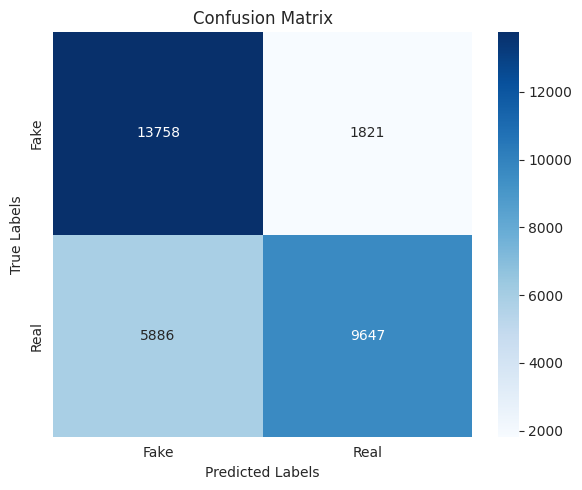

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming y_true and y_pred are already populated
cm = confusion_matrix(y_true, y_pred)
labels = ['Fake', 'Real']

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()


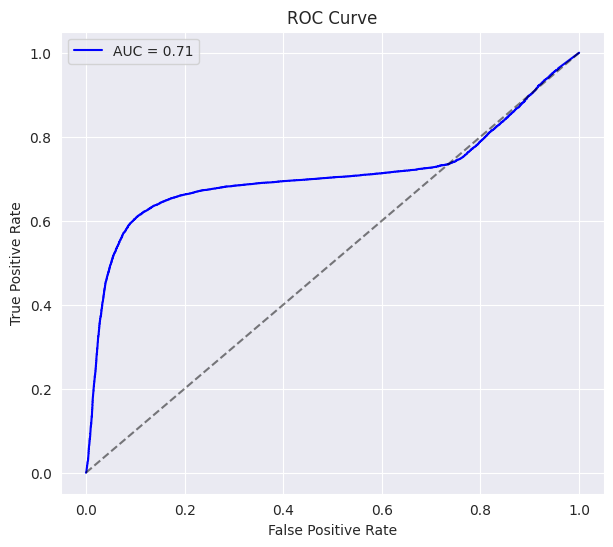

In [21]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc

def plot_roc_and_distribution(y_test, y_pred_probs):
    # Compute ROC curve and AUC
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(7, 6))

    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}', color='blue')
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()

# y_test: Ground truth labels
# y_pred: Model predictions, assumed to be probabilities

plot_roc_and_distribution(y_true, y_preds)

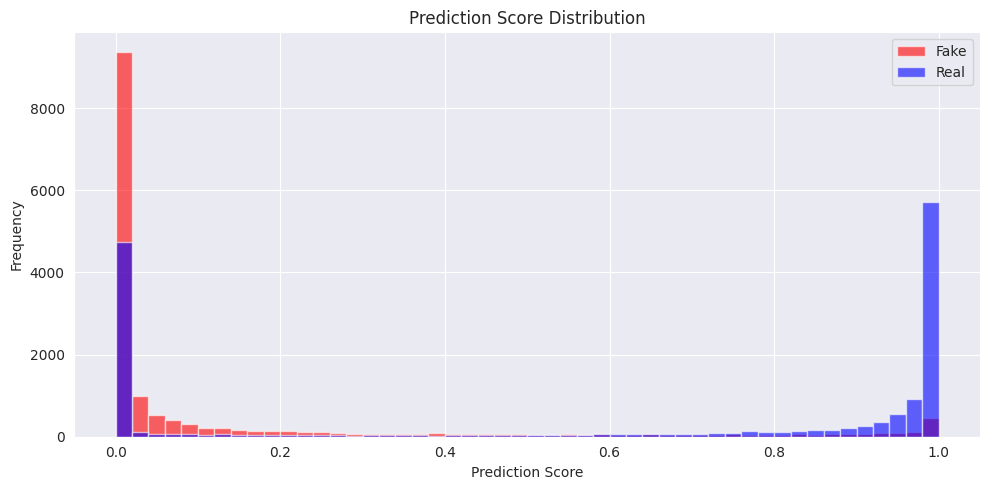

In [22]:
import matplotlib.pyplot as plt

def plot_prediction_distribution(predictions, labels):
    predictions = predictions.flatten()
    labels = labels.flatten()

    plt.figure(figsize=(10, 5))

    # Separate predictions by class
    fake_preds = predictions[labels == 0]
    real_preds = predictions[labels == 1]

    plt.hist(fake_preds, bins=50, alpha=0.6, label='Fake', color='red', range=(0, 1))
    plt.hist(real_preds, bins=50, alpha=0.6, label='Real', color='blue', range=(0, 1))

    plt.title("Prediction Score Distribution")
    plt.xlabel("Prediction Score")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_prediction_distribution(np.array(y_preds), np.array(y_true))

In [23]:
model.summary()

Model: "SRM-CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ srm_input (InputLayer)          │ (None, 256, 256, 15)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_1 (Functional)       │ (None, 8, 8, 128)      │       246,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv (Conv2D)            │ (None, 8, 8, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn (BatchNormalization)  │ (None, 8, 8, 64)       │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_lrelu (LeakyReLU)        │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_drop (Dropout)           │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv (Conv2D)            │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn (BatchNormalization)  │ (None, 8, 8, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_lrelu (LeakyReLU)        │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_drop (Dropout)           │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv (Conv2D)            │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn (BatchNormalization)  │ (None, 8, 8, 256)      │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_lrelu (LeakyReLU)        │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_drop (Dropout)           │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prob_fake (Dense)               │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,579,133 (6.02 MB)

 Trainable params: 443,969 (1.69 MB)

 Non-trainable params: 247,224 (965.72 KB)

 Optimizer params: 887,940 (3.39 MB)

In [ ]:
import matplotlib.pyplot as plt

def plot_prediction_distribution(predictions, labels):
    predictions = predictions.flatten()
    labels = labels.flatten()

    plt.figure(figsize=(10, 5))

    # Separate predictions by class
    fake_preds = predictions[labels == 0]
    real_preds = predictions[labels == 1]

    plt.hist(fake_preds, bins=50, alpha=0.6, label='Fake', color='red', range=(0, 1))
    plt.hist(real_preds, bins=50, alpha=0.6, label='Real', color='blue', range=(0, 1))

    plt.title("Prediction Score Distribution")
    plt.xlabel("Prediction Score")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_prediction_distribution(np.array(y_prob), np.array(y_true))